In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

The **Standardized Precipitation Index (SPI)** is a measure used to quantify the precipitation deficit or surplus for a specific timescale (e.g., 3-month, 6-month) and location. SPI values are calculated by comparing observed precipitation to a long-term statistical baseline, allowing us to classify and understand wet and dry conditions in a standardized way. Here’s a breakdown of what SPI values represent:

### SPI Value Ranges and Interpretation
SPI values are measured in terms of standard deviations from the mean and indicate either dry or wet conditions:

| SPI Value           | Category                  |
|---------------------|---------------------------|
| ≤ -2.0             | Extremely dry             |
| -1.5 to -1.99      | Severely dry              |
| -1.0 to -1.49      | Moderately dry            |
| -0.99 to 0.99      | Near normal               |
| 1.0 to 1.49        | Moderately wet            |
| 1.5 to 1.99        | Severely wet              |
| ≥ 2.0              | Extremely wet             |

### Explanation of Key Points
1. **Negative SPI Values**: Negative values indicate **drought conditions** or periods with below-average precipitation.
   - The more negative the SPI, the more intense the drought. For example, an SPI of -2.0 or lower is considered "extremely dry," representing a rare and significant drought.

2. **Positive SPI Values**: Positive values indicate **wet conditions** or periods with above-average precipitation.
   - The higher the positive SPI, the more intense the wet period. An SPI of 2.0 or higher is considered "extremely wet," indicating an unusual surplus of precipitation.

3. **Near-Zero SPI Values**: Values close to zero (between -0.99 and 0.99) suggest **normal conditions** or average precipitation compared to the historical baseline.

4. **Timescale Sensitivity**: The SPI timescale affects the interpretation:
   - A **3-month SPI** captures short-term weather patterns and is useful for identifying agricultural droughts.
   - A **6-month or 12-month SPI** captures longer-term climatic trends and can reflect hydrological conditions affecting groundwater or reservoir levels.

### Why SPI is Useful
- **Standardization**: Because SPI is normalized, it allows comparisons across regions with different climate patterns and across timescales.
- **Flexibility**: By adjusting the timescale, SPI can be tailored to monitor different types of drought or precipitation trends (e.g., short-term agricultural vs. long-term hydrological).
- **Decision Support**: SPI values help water managers, farmers, and policymakers make informed decisions regarding water use, drought management, and flood preparation.

### Example
If the SPI for a region is -1.8 over a 3-month period, this indicates a severe drought for that timescale and region. Conversely, an SPI of +1.8 over 6 months might indicate unusually wet conditions affecting water resources.

The SPI is thus a versatile and robust tool for assessing the impact of precipitation variability.


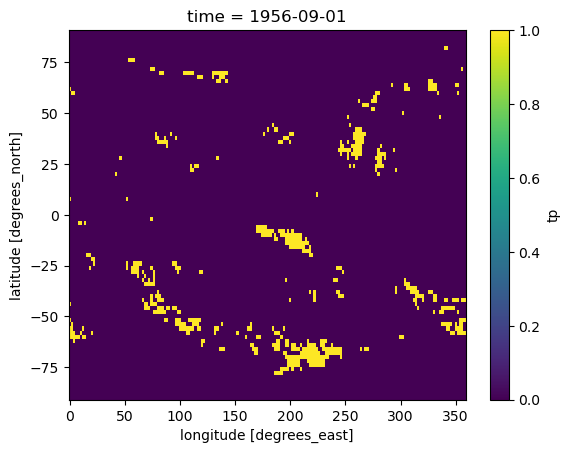

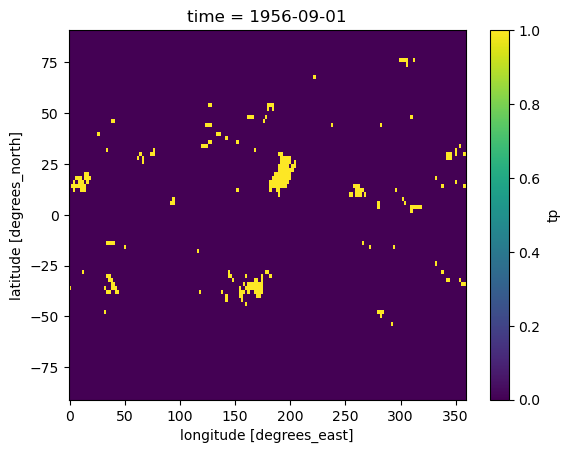

In [3]:
ds = xr.open_dataset('spi_12mon.nc')
spi = ds.tp
(ds.tp[200] <-2).plot()
plt.show()
(ds.tp[200] >2).plot()
plt.show()


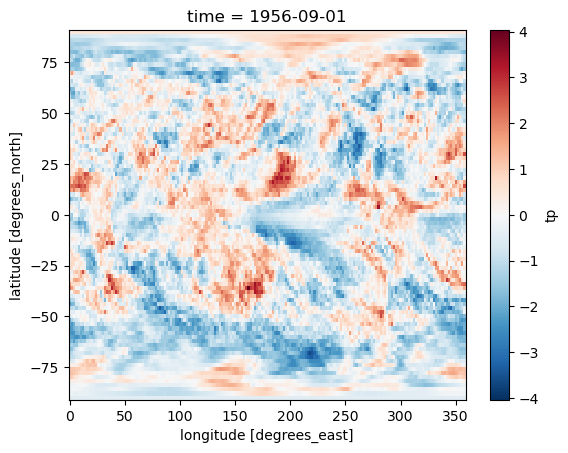

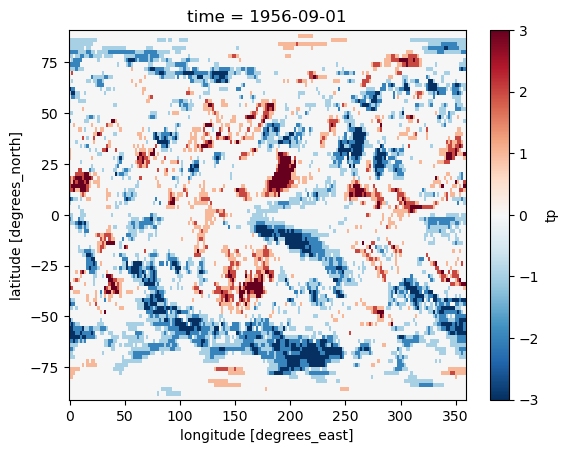

In [4]:
import xarray as xr
import numpy as np

def categorize_spi(spi):
    """
    Categorize SPI values into integer categories based on thresholds.

    Parameters:
        spi (xarray.DataArray): SPI values with dimensions ('time', 'latitude', 'longitude').

    Returns:
        xarray.DataArray: Categorical SPI data with the same dimensions as the input, using integers.
    """
    # Initialize an empty DataArray with the same coordinates and dimensions as spi, filled with zeros
    spi_categorical = xr.full_like(spi, 0, dtype="int")

    # Apply conditions for each category using integer codes
    spi_categorical = spi_categorical.where(spi <= 2.0, 3)                     # Extremely wet
    spi_categorical = spi_categorical.where((spi <= 1.5) | (spi > 2.0), 2)     # Severely wet
    spi_categorical = spi_categorical.where((spi <= 1.0) | (spi > 1.5), 1)     # Moderately wet
    spi_categorical = spi_categorical.where((spi < -1.0) | (spi > 1.0), 0)     # Near normal
    spi_categorical = spi_categorical.where((spi < -1.5) | (spi >= -1.0), -1)  # Moderately dry
    spi_categorical = spi_categorical.where((spi < -2.0) | (spi >= -1.5), -2)  # Severely dry
    spi_categorical = spi_categorical.where(spi >= -2.0, -3)                   # Extremely dry

    return spi_categorical

# Example usage
# Assuming 'spi' is an xarray.DataArray with SPI values calculated previously
spi_categorical = categorize_spi(spi)

# Print and verify
#print(spi_categorical)
spi[200].plot()
plt.show()
spi_categorical[200].plot()

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from ipywidgets import interact
import numpy as np

# Assuming 'spi_categorical' is the xarray DataArray with dimensions ('time', 'latitude', 'longitude')
# and contains integer values representing categories:
# -3 = Extremely dry, -2 = Severely dry, -1 = Moderately dry, 0 = Near normal,
# 1 = Moderately wet, 2 = Severely wet, 3 = Extremely wet

# Define the color map for SPI categories
category_colors = {
    -3: "darkred",       # Extremely dry
    -2: "red",           # Severely dry
    -1: "salmon",        # Moderately dry
     0: "white",     # Near normal
     1: "lightblue",     # Moderately wet
     2: "blue",          # Severely wet
     3: "darkblue"       # Extremely wet
}

# Create a ListedColormap based on the category colors
cmap = ListedColormap([category_colors[i] for i in sorted(category_colors.keys())])
norm = plt.Normalize(vmin=-3, vmax=3)

# Function to plot a specific time slice
def plot_spi(time_index):
    # Select the data for the specific time index
    spi_categorical_2d = spi_categorical.isel(time=time_index)

    # Plot with Cartopy
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_title(f"Categorized SPI at Time Index {time_index}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    # Plot the data
    img = ax.pcolormesh(
        spi_categorical_2d.longitude, spi_categorical_2d.latitude,
        spi_categorical_2d, cmap=cmap, norm=norm, transform=ccrs.PlateCarree()
    )
    
    # Add coastlines and features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
    
    # Add colorbar
    cbar = plt.colorbar(img, ax=ax, orientation="vertical", pad=0.02, ticks=np.arange(-3, 4))
    cbar.set_label("SPI Categories")
    cbar.set_ticks(sorted(category_colors.keys()))
    cbar.set_ticklabels([
        "Extremely dry", "Severely dry", "Moderately dry", "Near normal", 
        "Moderately wet", "Severely wet", "Extremely wet"
    ])
    
    plt.show()

# Interactive widget for selecting the time index
interact(plot_spi, time_index=(0, spi_categorical.sizes["time"] - 1))


interactive(children=(IntSlider(value=497, description='time_index', max=995), Output()), _dom_classes=('widge…

<function __main__.plot_spi(time_index)>

In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from ipywidgets import interact
import numpy as np

# Assuming 'spi_categorical' is the xarray DataArray with dimensions ('time', 'latitude', 'longitude')
# and contains integer values representing categories:
# -3 = Extremely dry, -2 = Severely dry, -1 = Moderately dry, 0 = Near normal,
# 1 = Moderately wet, 2 = Severely wet, 3 = Extremely wet

# Define the color map for SPI categories
category_colors = {
    -3: "darkred",       # Extremely dry
    -2: "red",           # Severely dry
    -1: "salmon",        # Moderately dry
     0: "lightgray",     # Near normal
     1: "lightblue",     # Moderately wet
     2: "blue",          # Severely wet
     3: "darkblue"       # Extremely wet
}

# Create a ListedColormap based on the category colors
cmap = ListedColormap([category_colors[i] for i in sorted(category_colors.keys())])
norm = plt.Normalize(vmin=-3, vmax=3)

# Function to plot a specific time slice with a polar stereographic projection
def plot_spi(time_index, hemisphere="north"):
    # Select the data for the specific time index
    spi_categorical_2d = spi_categorical.isel(time=time_index)
    
    # Choose projection based on hemisphere
    if hemisphere == "north":
        projection = ccrs.NorthPolarStereo()
        extent = [-180, 180, 60, 90]  # Extent for the Northern Hemisphere polar view
    else:
        projection = ccrs.SouthPolarStereo()
        extent = [-180, 180, -90, -60]  # Extent for the Southern Hemisphere polar view

    # Plot with Cartopy
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection})
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(f"Categorized SPI at Time Index {time_index} ({hemisphere.capitalize()} Pole)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    # Plot the data
    img = ax.pcolormesh(
        spi_categorical_2d.longitude, spi_categorical_2d.latitude,
        spi_categorical_2d, cmap=cmap, norm=norm, transform=ccrs.PlateCarree()
    )
    
    # Add coastlines and features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
    
    # Add colorbar
    cbar = plt.colorbar(img, ax=ax, orientation="vertical", pad=0.02, ticks=np.arange(-3, 4))
    cbar.set_label("SPI Categories")
    cbar.set_ticks(sorted(category_colors.keys()))
    cbar.set_ticklabels([
        "Extremely dry", "Severely dry", "Moderately dry", "Near normal", 
        "Moderately wet", "Severely wet", "Extremely wet"
    ])
    
    plt.show()

# Interactive widget for selecting the time index and hemisphere
interact(plot_spi, time_index=(0, spi_categorical.sizes["time"] - 1), hemisphere=["north", "south"])


interactive(children=(IntSlider(value=497, description='time_index', max=995), Dropdown(description='hemispher…

<function __main__.plot_spi(time_index, hemisphere='north')>

In [7]:
spicat = spi_categorical[11:]
spicat = spicat.where(~spicat.isin([-1, 0, 1]), np.nan)

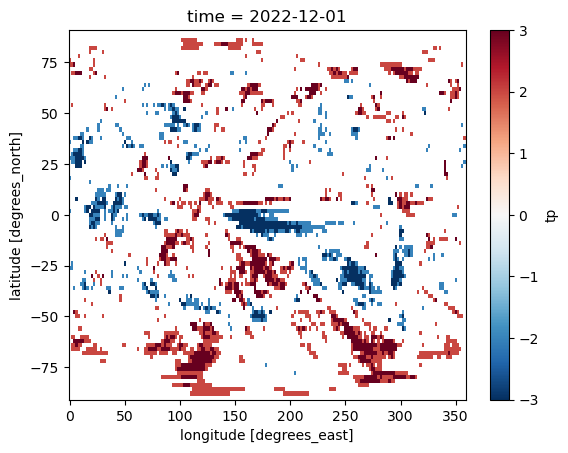

In [8]:
spicat[-1].plot()

In [9]:
# Sample data
series1 = spicat[:,10,10]
series2 = spicat[:,50,50]



In [10]:
from sklearn.metrics import cohen_kappa_score

In [11]:
series1 = spicat[:,10,10]
series2 = spicat[:,50,50]

agreement_percentage = np.mean(series1 == series2) * 100
print("Agreement Percentage:", agreement_percentage, "%")

# Filter out NaN values in both series
mask = ~np.isnan(series1) & ~np.isnan(series2)
filtered_series1 = series1[mask]
filtered_series2 = series2[mask]

# Calculate Cohen's Kappa Score on the filtered series
kappa_score = cohen_kappa_score(filtered_series1, filtered_series2)
print("Cohen's Kappa Score:", kappa_score)



Agreement Percentage: <xarray.DataArray 'tp' ()> Size: 8B
array(0.20304569) %
Cohen's Kappa Score: -0.3157894736842106


In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
import itertools
import xarray as xr

# Example: Assuming spicat is an xarray.DataArray with dimensions (time, lat, lon)
# spicat = xr.DataArray(...)

# Get latitude and longitude dimensions
lat_dim, lon_dim = spicat.shape[1], spicat.shape[2]
lat_dim, lon_dim = 5, 5 #spicat.shape[1], spicat.shape[2]

# Generate all unique coordinate pairs
coord_pairs = list(itertools.combinations([(i, j) for i in range(lat_dim) for j in range(lon_dim)], 2))

# Initialize lists to store results
results = []

# Loop through each pair of coordinates
for (i, j), (m, n) in coord_pairs:
    # Extract time series for each coordinate pair
    series1 = spicat[:, i, j].values
    series2 = spicat[:, m, n].values

    # Calculate agreement percentage
    agreement_percentage = np.nanmean(series1 == series2) * 100

    # Filter out NaN values
    mask = ~np.isnan(series1) & ~np.isnan(series2)
    filtered_series1 = series1[mask]
    filtered_series2 = series2[mask]

    # Calculate Cohen's Kappa Score, handling empty cases
    kappa_score = cohen_kappa_score(filtered_series1, filtered_series2) if len(filtered_series1) > 0 else np.nan

    # Append results to the list
    results.append({
        "Coordinate Pair": ((i, j), (m, n)),
        "Agreement Percentage (%)": agreement_percentage,
        "Cohen's Kappa Score": kappa_score
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display the DataFrame
print(results_df)


      Coordinate Pair  Agreement Percentage (%)  Cohen's Kappa Score
0    ((0, 0), (0, 1))                 12.385787             1.000000
1    ((0, 0), (0, 2))                 12.385787             1.000000
2    ((0, 0), (0, 3))                 12.385787             1.000000
3    ((0, 0), (0, 4))                 12.385787             1.000000
4    ((0, 0), (1, 0))                  5.786802             0.595421
..                ...                       ...                  ...
295  ((4, 1), (4, 3))                  6.497462             0.617772
296  ((4, 1), (4, 4))                  5.482234             0.580412
297  ((4, 2), (4, 3))                  9.340102             0.812697
298  ((4, 2), (4, 4))                  7.411168             0.690187
299  ((4, 3), (4, 4))                  9.644670             0.785624

[300 rows x 3 columns]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
import itertools
import xarray as xr

# Example: Assuming spicat is an xarray.DataArray with dimensions (time, lat, lon)
# spicat = xr.DataArray(...)

# Convert spicat to float32 for memory efficiency
spicat = spicat.astype(np.float16)

# Get latitude and longitude dimensions
lat_dim, lon_dim = spicat.shape[1], spicat.shape[2]

# Generate all unique coordinate pairs
coord_pairs = list(itertools.combinations([(i, j) for i in range(lat_dim) for j in range(lon_dim)], 2))

# Initialize lists to store results
results = []

# Loop through each pair of coordinates
for (i, j), (m, n) in coord_pairs:
    # Extract time series for each coordinate pair as float32
    series1 = spicat[:, i, j].values.astype(np.float32)
    series2 = spicat[:, m, n].values.astype(np.float32)

    # Calculate agreement percentage, casting to float32
    agreement_percentage = np.nanmean((series1 == series2).astype(np.float32)) * 100

    # Filter out NaN values
    mask = ~np.isnan(series1) & ~np.isnan(series2)
    filtered_series1 = series1[mask].astype(np.float32)
    filtered_series2 = series2[mask].astype(np.float32)

    # Calculate Cohen's Kappa Score, handling empty cases
    kappa_score = cohen_kappa_score(filtered_series1, filtered_series2) if len(filtered_series1) > 0 else np.nan

    # Append results to the list
    results.append({
        "Coordinate Pair": ((i, j), (m, n)),
        "Agreement Percentage (%)": agreement_percentage,
        "Cohen's Kappa Score": kappa_score
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display the DataFrame
print(results_df)


/Users/doan/anaconda3_2023.09-0/envs/wrf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/doan/anaconda3_2023.09-0/envs/wrf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:730: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/doan/anaconda3_2023.09-0/envs/wrf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/doan/anaconda3_2023.09-0/envs/wrf/lib/python3.11/site-packages/sklearn/metrics/_classification.py:730: RuntimeWarning: invalid value encountered in scalar divide
  k = np.su

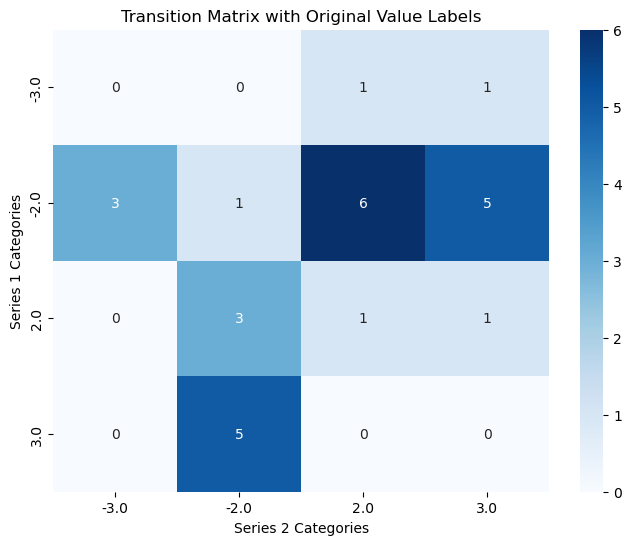

In [63]:
# Filter out NaN values in both series
mask = ~np.isnan(series1) & ~np.isnan(series2)
filtered_series1 = series1[mask]
filtered_series2 = series2[mask]

# Get unique original values (excluding NaNs) from both series
unique_values = np.unique(np.concatenate((filtered_series1, filtered_series2)))

# Compute the confusion matrix with original values as labels
transition_matrix = confusion_matrix(filtered_series1, filtered_series2, labels=unique_values)

# Visualize the transition matrix with original values as tick labels
plt.figure(figsize=(8, 6))
sns.heatmap(transition_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=unique_values, yticklabels=unique_values)
plt.xlabel("Series 2 Categories")
plt.ylabel("Series 1 Categories")
plt.title("Transition Matrix with Original Value Labels")
plt.show()

In [61]:
# Plotting histogram of unique values in series1
plt.figure(figsize=(8, 5))
plt.hist(series1, bins=np.arange(min(series1)-0.5, max(series1)+1.5, 1), edgecolor='black')
plt.xlabel("Unique Values")
plt.ylabel("Frequency")
plt.title("Histogram of Unique Values in Series1")
plt.xticks(np.arange(min(series1), max(series1) + 1))
plt.show()

ValueError: arange: cannot compute length

<Figure size 800x500 with 0 Axes>